In [70]:
%load_ext autoreload
%autoreload 2

from multicamera_acquisition.acquisition import refactor_acquire_video, AcquisitionLoop
from multicamera_acquisition.writer import NVC_Writer, FFMPEG_Writer
from multicamera_acquisition.interfaces.microcontroller import Microcontroller 
from multicamera_acquisition.visualization import MultiDisplay
from multicamera_acquisition.interfaces.config import (
    partial_config_from_camera_list,
    create_full_camera_default_config,
)
import os
from glob import glob
import logging


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:

def reset_loggers():
    # Remove handlers from all loggers
    for logger in logging.Logger.manager.loggerDict.values():
        if isinstance(logger, logging.Logger):  # Guard against 'PlaceHolder' objects
            logger.handlers.clear()

    # Reset the root logger
    logging.getLogger().handlers.clear()

In [72]:
camera_list = [
    {"name": "top",    "brand": "basler", "id": "40393557", "gain": 20, "exposure": 1000, "roi": (128,0,1440,1200), "gamma": 0.7,},
]


# Recording params
rec_time_s = 0.25 * 60
fps = 60
tmp_path = R'D:\Jonah\2023_12_26_6cam_testing\tmp'
logging_level = "INFO"


In [73]:
if not os.path.exists(tmp_path):
    os.makedirs(tmp_path)

In [74]:
partial_new_config = partial_config_from_camera_list(camera_list)

# Add writer configs to each ir camera config
for camera_name in partial_new_config["cameras"].keys():
    if partial_new_config["cameras"][camera_name]["brand"] != "basler":
        continue
    ir_writer_config = NVC_Writer.default_writer_config(fps).copy()
    ir_writer_config["camera_name"] = camera_name
    partial_new_config["cameras"][camera_name]["writer"] = ir_writer_config


In [75]:
# Set the trigger behavior
for camera in camera_list[:6]:
    camera["trigger"] = {
        'acquisition_mode': 'Continuous',
        'trigger_activation': 'RisingEdge',
        'trigger_selector': 'FrameStart',
        'trigger_source': 'Line2',
    }

In [76]:
# make the full config, filling in defaults where necessary
full_config = create_full_camera_default_config(partial_new_config, fps)
full_config["globals"] = {}
full_config["globals"]["fps"] = fps
full_config["globals"]["microcontroller_required"] = False

# Set up the acquisition loop part of the config
acq_config = AcquisitionLoop.default_acq_loop_config().copy()
full_config["acq_loop"] = acq_config

# Set up the Microcontroller part of the config
full_config["microcontroller"] = {}

full_config["rt_display"] = MultiDisplay.default_MultiDisplay_config()

In [77]:
reset_loggers()

save_loc, full_config = refactor_acquire_video(
    tmp_path,
    full_config,
    recording_duration_s=rec_time_s,
    append_datetime=True,
    overwrite=True,
    logging_level=logging_level
)

2024-11-04 16:08:13,506 - main_acq_logger - INFO - Starting recording...
2024-11-04 16:08:15,809 - main_acq_logger - INFO - Opening subprocesses and cameras, this may take a moment...
2024-11-04 16:08:17,396 - main_acq_logger - INFO - Starting cameras...


Recording Progress: 160.0% (24 / 15.0 sec))

2024-11-04 16:08:42,421 - main_acq_logger - INFO - Ending processes, this may take a moment...
2024-11-04 16:08:42,935 - main_acq_logger - INFO - Processes ended
2024-11-04 16:08:42,935 - main_acq_logger - INFO - Done.


Recording Progress: 100%

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
metadata_file = list(save_loc.glob("*.metadata.csv"))[0]
metadata = pd.read_csv(metadata_file, header=0)

In [80]:
metadata.head()

,frames_received,frame_timestamp,frame_image_uid,queue_size,line_status
0,1,2204598238337580,1.730754e+09,0,NaN
1,2,2204598254337810,1.730754e+09,9,NaN
2,3,2204598270338030,1.730754e+09,8,NaN
3,4,2204598286338250,1.730754e+09,7,NaN
4,5,2204598302338470,1.730754e+09,6,NaN


In [81]:
np.median(np.diff(metadata.frame_timestamp.values))/1e9

0.01600022

Text(0.5, 0, 'Inter-frame diffs (msec)')

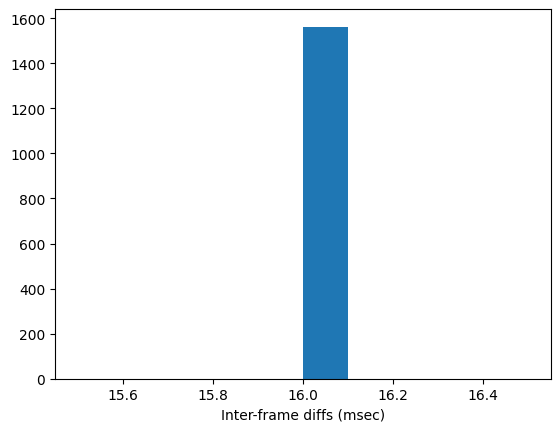

In [82]:
diffs = np.round(np.diff(metadata.frame_timestamp.values) / 1e6)
plt.hist(diffs)
plt.xlabel("Inter-frame diffs (msec)")